# Graph-Based Fake Review Detection — Reviewer–Restaurant Networks
**Project Group 4** · Smeh Diab, Nir Levon, Shir Fox, Neta Nachteiler

CRISP-DM phases covered in this notebook: **Data Understanding (EDA) → Data Preparation → Modeling → Evaluation**.

**Goal.** Detect fake / filtered Yelp restaurant reviews. We compare a **text-only baseline**
(the "previous / standard" approach) against models that add **reviewer–restaurant graph features
and behavioral signals** (our contribution), and a **hybrid** of both.

**How to read this notebook.** Cells are ordered top-to-bottom and run end-to-end.
Each numbered section maps to a slide block in the presentation:
1. Problem / motivation → slides (see business doc)
2. Data description → **§1 + §2 (EDA)**
3. Previous solution / SOTA → **§7.1 text-only baseline**
4. Our solution → **§4–§7.2/§7.3 graph + hybrid**, evaluated in **§8**


## 0 · Setup & configuration

In [1]:
# If running on Google Colab, xgboost is usually preinstalled. If not, uncomment:
# !pip -q install xgboost networkx scikit-learn

import os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 60)
print("Environment ready.")

Environment ready.


## 1 · Load the data  *(CRISP-DM: Collect Initial Data)*

The dataset has two **tab-separated** files: `new_data_train.csv` and `new_data_test.csv`.
Each row = one review. The label column is **`flagged`** (1 = fake / filtered, 0 = genuine).

**On Colab**, pick ONE option below:
- **A. Upload** the two CSVs (or the `archive.zip`) with the file picker.
- **B. Mount Google Drive** and point `DATA_DIR` to the folder.


In [2]:
# ---- Option A: upload from your computer (Colab) ----
# from google.colab import files
# up = files.upload()           # choose new_data_train.csv and new_data_test.csv (or the zip)
# # if you uploaded the zip:
# # !unzip -o archive*.zip -d data
# DATA_DIR = "."                # or "data"

# ---- Option B: Google Drive ----
# from google.colab import drive; drive.mount("/content/drive")
# DATA_DIR = "/content/drive/MyDrive/your_folder"

# ---- Local / already-present files ----
DATA_DIR = "."                  # folder containing the two CSVs

TRAIN_PATH = os.path.join(DATA_DIR, "new_data_train.csv")
TEST_PATH  = os.path.join(DATA_DIR, "new_data_test.csv")

In [3]:
RENAME = {
    "reviewID": "review_id", "reviewerID": "reviewer_id", "restaurantID": "restaurant_id",
    "date": "date", "rating": "rating", "flagged": "label", "reviewContent": "review_text",
}

def load(path):
    # Files are TAB-separated with an unnamed leading index column.
    df = pd.read_csv(path, sep="\t", index_col=0).rename(columns=RENAME)
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["review_text"] = df["review_text"].fillna("")
    return df.reset_index(drop=True)

train = load(TRAIN_PATH)
test  = load(TEST_PATH)
print("train:", train.shape, "| test:", test.shape)
train.head(3)

train: (9929, 22) | test: (2483, 22)


,review_id,reviewer_id,restaurant_id,date,rating,reviewUsefulCount,review_text,label,name,location,yelpJoinDate,friendCount,reviewCount,firstCount,usefulCount,coolCount,funnyCount,complimentCount,tipCount,fanCount,restaurantRating,ReviewLength
0,Z_wgGcI8_Txo87Wz7CxdrQ,cM9GIlk61Qh2thLyJyxNyA,N7juvW8YoFIj7sEBzVF8GQ,2010-09-17,5,0,as new resident chicago los angeles i mission ...,1,suzie n.,"Los Angeles, CA",July 2009,0,1,0,1,2,0,0,0,0,4.0,144
1,NJfQb03MSstqYagt860Oaw,SVlSPBnjCzY2Bu9n8y2C5A,o54U2VkQama8FI30qDkWvw,2008-01-31,5,0,great place rarely wait fairly easy find parki...,0,Jacqui B.,"Kalamazoo, MI",January 2008,5,12,2,19,7,6,4,0,0,4.0,46
2,2uao3bK9iSV4fuMwuSYCiQ,5HYWhPS3ozYifieW0lWMUw,1QKqtC4vML3QhkrSzwR_tQ,2010-03-31,5,0,back bar makes feel though transported china s...,1,Mike A.,"Los Angeles, CA",March 2010,0,6,0,7,3,2,0,0,0,3.5,18


In [4]:
# Column inventory
print("Columns:", list(train.columns))
print("\nLabel balance (train):")
print(train["label"].value_counts(normalize=True).round(3).rename({0:"genuine",1:"fake"}))
print("\nLabel balance (test):")
print(test["label"].value_counts(normalize=True).round(3).rename({0:"genuine",1:"fake"}))

Columns: ['review_id', 'reviewer_id', 'restaurant_id', 'date', 'rating', 'reviewUsefulCount', 'review_text', 'label', 'name', 'location', 'yelpJoinDate', 'friendCount', 'reviewCount', 'firstCount', 'usefulCount', 'coolCount', 'funnyCount', 'complimentCount', 'tipCount', 'fanCount', 'restaurantRating', 'ReviewLength']

Label balance (train):
label
genuine    0.503
fake       0.497
Name: proportion, dtype: float64

Label balance (test):
label
fake       0.512
genuine    0.488
Name: proportion, dtype: float64


## 2 · Exploratory Data Analysis  *(slide: "Data description")*

Key questions from the Data-Understanding report:
the label balance, rating behavior by label, review length, activity over time,
and the **graph shape** (reviewer vs restaurant degree).

In [5]:
# Quick structural summary used throughout the notebook
n_reviews   = len(train)
n_reviewers = train.reviewer_id.nunique()
n_rests     = train.restaurant_id.nunique()
print(f"reviews={n_reviews:,} | reviewers={n_reviewers:,} | restaurants={n_rests:,}")
print(f"date range: {train.date.min().date()} -> {train.date.max().date()}")
rpr = train.groupby('reviewer_id').size()
rpb = train.groupby('restaurant_id').size()
print(f"reviewers with exactly 1 review: {(rpr==1).mean()*100:.1f}%")
print(f"reviews per restaurant: mean={rpb.mean():.1f}, max={rpb.max()}")

reviews=9,929 | reviewers=8,332 | restaurants=104
date range: 2005-04-15 -> 2012-09-23
reviewers with exactly 1 review: 87.5%
reviews per restaurant: mean=95.5, max=245


**Structural takeaway (drives the whole graph design).** The bipartite graph is *lopsided*:
~100 restaurants act as high-degree hubs (≈95 reviews each), while ~88% of reviewers appear only
**once**. So reviewer-degree alone is weak — the useful structure lives in **restaurant-level
aggregates, rating deviations, temporal bursts, and reviewer profile/behavioral stats**.

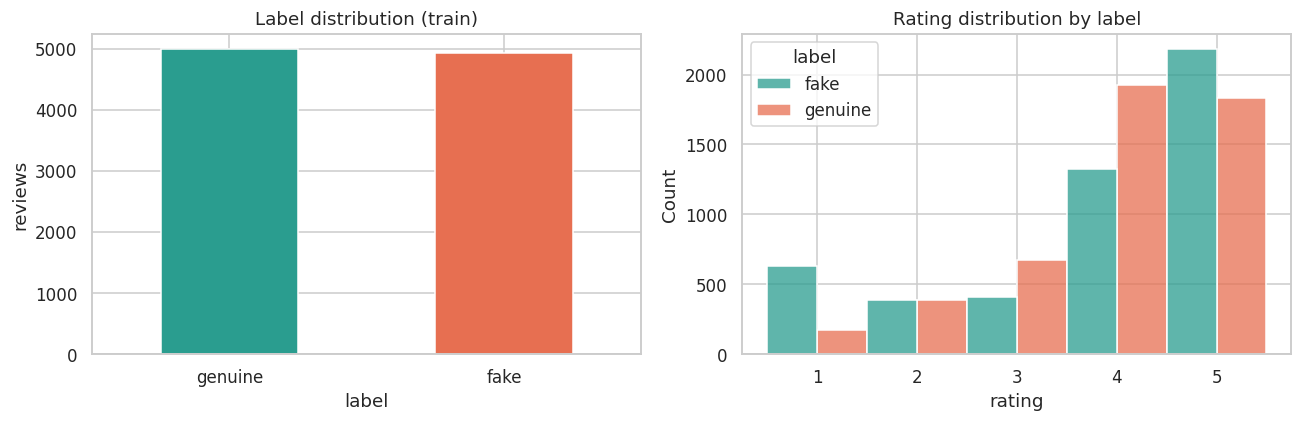

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
train["label"].map({0:"genuine",1:"fake"}).value_counts().plot.bar(ax=ax[0], color=["#2a9d8f","#e76f51"])
ax[0].set_title("Label distribution (train)"); ax[0].set_ylabel("reviews"); ax[0].tick_params(axis="x", rotation=0)
sns.histplot(data=train, x="rating", hue=train["label"].map({0:"genuine",1:"fake"}),
             multiple="dodge", discrete=True, ax=ax[1], palette=["#2a9d8f","#e76f51"])
ax[1].set_title("Rating distribution by label")
plt.tight_layout(); plt.show()

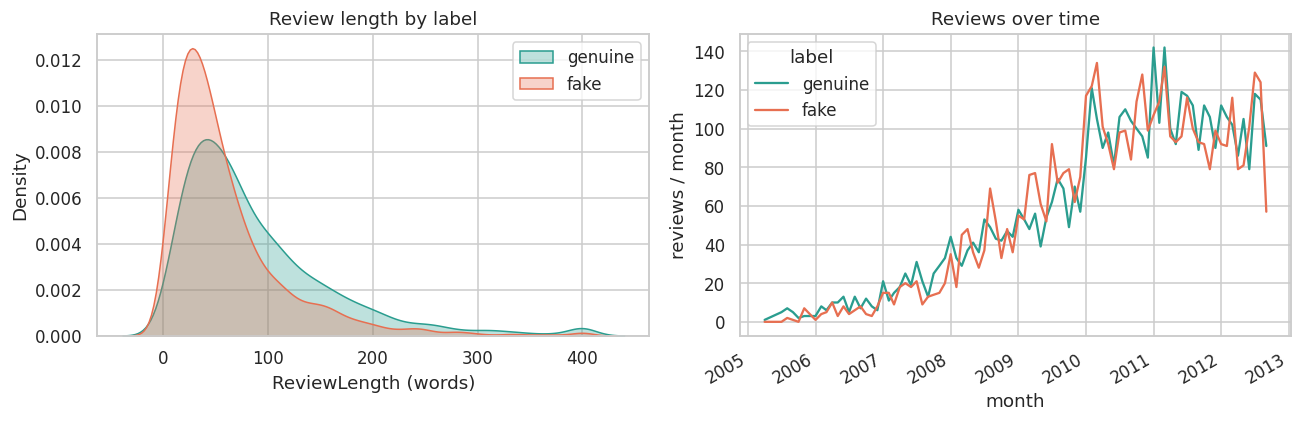

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
for lab,c,name in [(0,"#2a9d8f","genuine"),(1,"#e76f51","fake")]:
    sns.kdeplot(train.loc[train.label==lab,"ReviewLength"].clip(upper=400),
                ax=ax[0], color=c, fill=True, alpha=.3, label=name)
ax[0].set_title("Review length by label"); ax[0].set_xlabel("ReviewLength (words)"); ax[0].legend()

ts = (train.assign(month=train.date.dt.to_period("M").dt.to_timestamp())
            .groupby(["month","label"]).size().unstack(fill_value=0)
            .rename(columns={0:"genuine",1:"fake"}))
ts.plot(ax=ax[1], color=["#2a9d8f","#e76f51"])
ax[1].set_title("Reviews over time"); ax[1].set_ylabel("reviews / month")
plt.tight_layout(); plt.show()

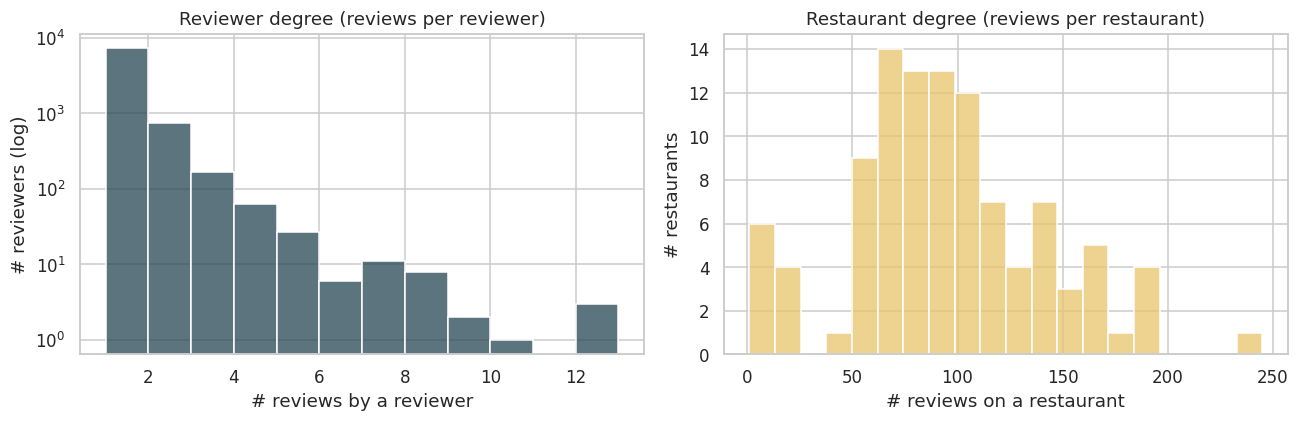

In [8]:
# Degree distributions (graph shape)
fig, ax = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(rpr.values, bins=range(1, rpr.max()+2), ax=ax[0], color="#264653")
ax[0].set_title("Reviewer degree (reviews per reviewer)"); ax[0].set_yscale("log")
ax[0].set_xlabel("# reviews by a reviewer"); ax[0].set_ylabel("# reviewers (log)")
sns.histplot(rpb.values, bins=20, ax=ax[1], color="#e9c46a")
ax[1].set_title("Restaurant degree (reviews per restaurant)")
ax[1].set_xlabel("# reviews on a restaurant"); ax[1].set_ylabel("# restaurants")
plt.tight_layout(); plt.show()

,genuine,fake
reviewUsefulCount,0.99,0.00
friendCount,60.06,2.58
reviewCount,122.29,7.13
usefulCount,274.11,3.24
fanCount,7.34,0.08
firstCount,11.14,0.25
ReviewLength,89.29,61.09


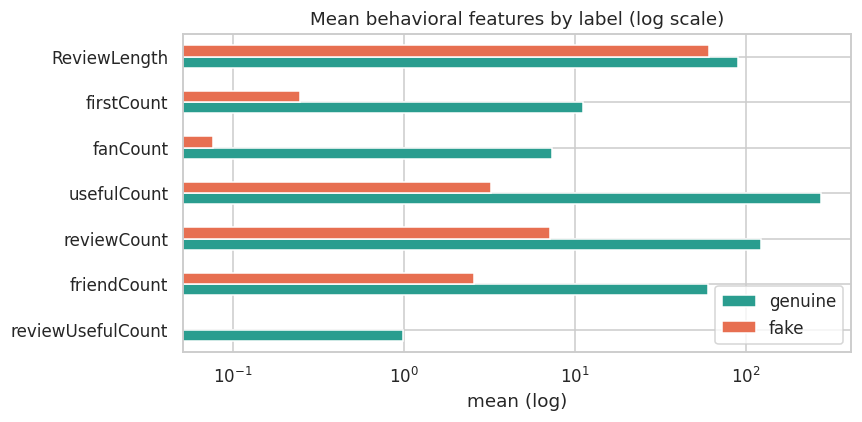

In [9]:
# Behavioral profile signal: fake reviewers tend to have near-empty profiles
behav_preview = ["reviewUsefulCount","friendCount","reviewCount","usefulCount",
                 "fanCount","firstCount","ReviewLength"]
comp = train.groupby("label")[behav_preview].mean().T
comp.columns = ["genuine","fake"]
display(comp.round(2))

ax = comp.plot.barh(figsize=(8,4), color=["#2a9d8f","#e76f51"], logx=True)
ax.set_title("Mean behavioral features by label (log scale)"); ax.set_xlabel("mean (log)")
plt.tight_layout(); plt.show()

**EDA findings (initial hypotheses, confirmed).**
- Dataset is **balanced** (~50/50) — so plain accuracy is meaningful, but we still report PR-AUC / F1.
- Fake reviews skew slightly toward extreme/high ratings and are **shorter** on average.
- The strongest separation is **behavioral**: fake reviewers have tiny `friendCount`, `reviewCount`,
  `fanCount`, and their reviews receive **zero** useful votes (`reviewUsefulCount`).
  → This is exactly the kind of *interaction / reputation* signal the graph approach is built to exploit.

## 3 · Data preparation  *(CRISP-DM: Select / Clean / Construct / Format)*

We standardize identifiers, validate fields, drop exact duplicates, and — importantly —
**check for leakage** before building features.

In [10]:
# 3.1 Cleaning: duplicates, missing text, valid ratings/dates
def clean(df):
    df = df.drop_duplicates(subset="review_id").copy()
    df["review_text"] = df["review_text"].fillna("").astype(str)
    df = df[df["rating"].between(1,5)]
    return df

before = (len(train), len(test))
train, test = clean(train), clean(test)
print("rows before -> after cleaning:", before, "->", (len(train), len(test)))
print("missing review_text:", (train.review_text.str.len()==0).sum(),
      "| invalid dates:", train.date.isna().sum())

rows before -> after cleaning: (9929, 2483) -> (9929, 2483)
missing review_text: 3 | invalid dates: 0


In [11]:
# 3.2 Leakage check — does any single column perfectly separate the label?
num_cols = train.select_dtypes("number").columns.drop("label")
report_rows = []
for c in num_cols:
    fake_max = train.loc[train.label==1, c].max()
    gen_min  = train.loc[train.label==0, c].min()
    # crude separability: AUC of the single feature
    from sklearn.metrics import roc_auc_score
    auc = roc_auc_score(train.label, train[c])
    report_rows.append((c, round(max(auc,1-auc),3)))
sep = pd.DataFrame(report_rows, columns=["feature","single_feat_AUC"]).sort_values(
    "single_feat_AUC", ascending=False)
display(sep.head(8))
print("No feature reaches AUC=1.0 -> no hard leakage. "
      "reviewUsefulCount is a strong ONE-DIRECTIONAL signal (==0 for all fake), "
      "but =0 for many genuine too, so it is a legitimate behavioral feature, not a label copy.")

,feature,single_feat_AUC
5,usefulCount,0.899
3,reviewCount,0.894
6,coolCount,0.875
7,funnyCount,0.869
2,friendCount,0.864
8,complimentCount,0.841
4,firstCount,0.764
10,fanCount,0.751


No feature reaches AUC=1.0 -> no hard leakage. reviewUsefulCount is a strong ONE-DIRECTIONAL signal (==0 for all fake), but =0 for many genuine too, so it is a legitimate behavioral feature, not a label copy.


**Cleaning / formatting decisions (per the Data-Prep report).**
- `flagged → label` is already binary (1 = fake, 0 = genuine); no remapping needed.
- Reviewer profile stats (`friendCount`, `reviewCount`, …) are **constant within a reviewer**
  (verified) — they are profile snapshots available at prediction time, so they are valid predictors.
- All aggregate / graph features below are computed on **train only** and mapped onto test,
  to avoid train→test leakage.

## 4 · Build the reviewer–restaurant graph  *(NetworkX, bipartite)*

Reviewers and restaurants are **nodes**; each review is an **edge** carrying `rating`, `date`, `label`.
We build the graph from training reviews and use it to (a) visualize structure and
(b) derive graph features in §5.

In [12]:
# 4.1 Bipartite graph from training reviews
G = nx.Graph()
G.add_nodes_from(("u_"+train.reviewer_id).unique(),   bipartite="reviewer")
G.add_nodes_from(("b_"+train.restaurant_id).unique(), bipartite="restaurant")
G.add_edges_from(zip("u_"+train.reviewer_id, "b_"+train.restaurant_id))
n_u = sum(1 for _,d in G.nodes(data=True) if d["bipartite"]=="reviewer")
n_b = sum(1 for _,d in G.nodes(data=True) if d["bipartite"]=="restaurant")
print(f"nodes={G.number_of_nodes():,} (reviewers={n_u:,}, restaurants={n_b:,}) | edges={G.number_of_edges():,}")
print(f"connected components: {nx.number_connected_components(G)}")

nodes=8,436 (reviewers=8,332, restaurants=104) | edges=9,929
connected components: 3


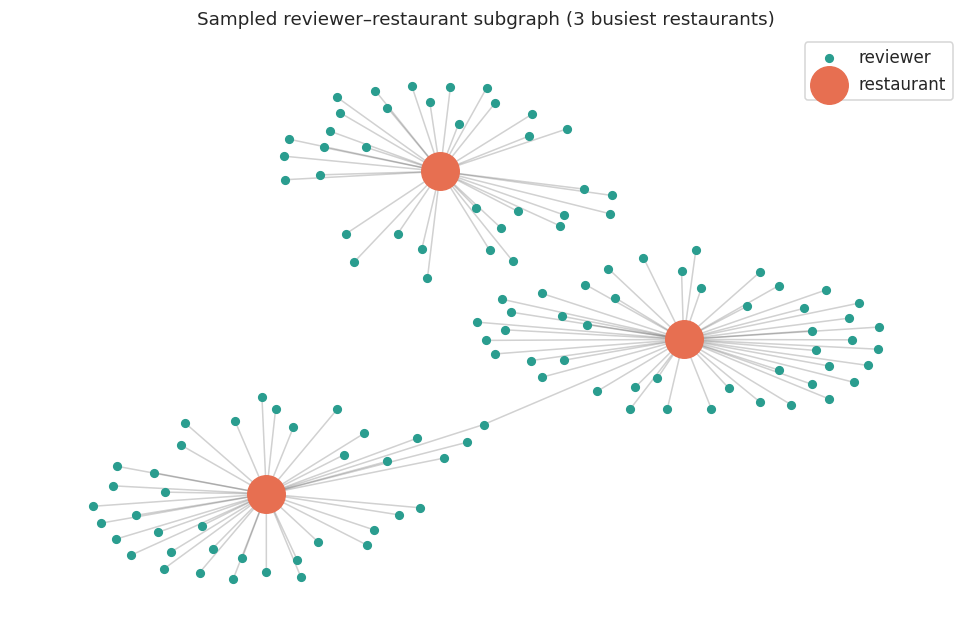

In [13]:
# 4.2 Visualize a sampled subgraph around a few busy restaurants (for the slides)
top_rests = train.restaurant_id.value_counts().head(3).index
sub_reviewers = train.loc[train.restaurant_id.isin(top_rests), "reviewer_id"].unique()[:120]
nodes = ["b_"+r for r in top_rests] + ["u_"+u for u in sub_reviewers]
H = G.subgraph([n for n in nodes if n in G]).copy()

pos = nx.spring_layout(H, seed=RANDOM_STATE, k=0.25)
plt.figure(figsize=(9,6))
rests = [n for n in H if n.startswith("b_")]; revs = [n for n in H if n.startswith("u_")]
nx.draw_networkx_edges(H, pos, alpha=0.2)
nx.draw_networkx_nodes(H, pos, nodelist=revs,  node_size=25,  node_color="#2a9d8f", label="reviewer")
nx.draw_networkx_nodes(H, pos, nodelist=rests, node_size=600, node_color="#e76f51", label="restaurant")
plt.legend(scatterpoints=1); plt.title("Sampled reviewer–restaurant subgraph (3 busiest restaurants)")
plt.axis("off"); plt.tight_layout(); plt.show()

## 5 · Feature engineering  *(graph + behavioral)*

All aggregates are learned on **train only** (leakage-safe) and mapped onto both splits.

In [14]:
# 5.1 Restaurant-level aggregates (graph hub statistics) — TRAIN ONLY
g = train.groupby("restaurant_id")
rest_stats = pd.DataFrame({
    "rest_deg":        g.size(),
    "rest_mean_rating":g.rating.mean(),
    "rest_std_rating": g.rating.std().fillna(0),
})
GLOBAL_RATING = train.rating.mean()

# 5.2 Reviewer-level degree — TRAIN ONLY
rev_deg = train.groupby("reviewer_id").size().rename("reviewer_deg")

def engineer(df):
    df = df.merge(rest_stats, left_on="restaurant_id", right_index=True, how="left")
    df = df.merge(rev_deg,    left_on="reviewer_id",   right_index=True, how="left")
    # unseen restaurants/reviewers in test -> safe fallbacks
    df["rest_deg"]         = df["rest_deg"].fillna(0)
    df["rest_mean_rating"] = df["rest_mean_rating"].fillna(GLOBAL_RATING)
    df["rest_std_rating"]  = df["rest_std_rating"].fillna(0)
    df["reviewer_deg"]     = df["reviewer_deg"].fillna(0)
    # edge/review derived feature: how far this rating is from the restaurant's norm
    df["rating_dev_rest"]  = df["rating"] - df["rest_mean_rating"]
    return df

train = engineer(train)
test  = engineer(test)
print("engineered features added.")

engineered features added.


In [15]:
# 5.3 Final structured feature set = behavioral profile + graph-derived
BEHAVIORAL = ["friendCount","reviewCount","firstCount","usefulCount","coolCount",
              "funnyCount","complimentCount","tipCount","fanCount",
              "reviewUsefulCount","restaurantRating","ReviewLength"]
GRAPH      = ["rest_deg","rest_mean_rating","rest_std_rating","rating_dev_rest",
              "reviewer_deg","rating"]
STRUCT_COLS = BEHAVIORAL + GRAPH
print(f"{len(STRUCT_COLS)} structured features:\n  behavioral: {BEHAVIORAL}\n  graph:      {GRAPH}")
train[STRUCT_COLS].describe().T.round(2).head()

18 structured features:
  behavioral: ['friendCount', 'reviewCount', 'firstCount', 'usefulCount', 'coolCount', 'funnyCount', 'complimentCount', 'tipCount', 'fanCount', 'reviewUsefulCount', 'restaurantRating', 'ReviewLength']
  graph:      ['rest_deg', 'rest_mean_rating', 'rest_std_rating', 'rating_dev_rest', 'reviewer_deg', 'rating']


,count,mean,std,min,25%,50%,75%,max
friendCount,9929.0,31.49,161.62,0.0,0.0,1.0,13.0,3945.0
reviewCount,9929.0,65.05,175.62,1.0,3.0,10.0,42.0,2162.0
firstCount,9929.0,5.73,34.04,0.0,0.0,0.0,1.0,834.0
usefulCount,9929.0,139.48,771.63,0.0,1.0,5.0,35.0,19452.0
coolCount,9929.0,97.53,640.03,0.0,0.0,1.0,13.0,17199.0


## 5b · Advanced graph feature engineering  *(train-only, no leakage)*

> **What changed & why.** An earlier version computed these features on
> `uni = pd.concat([train, test])` **before** building the graph. That leaks information:
> test edges shaped the graph structure (PageRank, components, Jaccard) and test rows entered
> the reviewer/restaurant rating means — values later used to train and evaluate the model.
>
> **Fix.** Every statistic below is **learned from the TRAIN graph / TRAIN rows only**, stored as a
> per-reviewer or per-restaurant lookup, then **mapped** onto both train and test by id. Test never
> contributes to feature generation. Reviewers/restaurants that appear only in test get documented
> **fallbacks**:
> - graph stats (degree, PageRank, betweenness, component size, Jaccard) → **0** (an unseen node has
>   no learned structure);
> - rating means → **global TRAIN mean rating** (so the deviation is measured against the corpus norm);
> - `average_days_between_reviews` → **-1** (undefined for unseen / single-review reviewers);
> - burst counts → **0** (no known prior activity).

In [16]:
# 5b.0 Build the graph from TRAIN data ONLY (previously this used train+test -> leakage)
Gtr = nx.Graph()
Gtr.add_nodes_from(("u_"+train.reviewer_id).unique(),   bipartite="reviewer")
Gtr.add_nodes_from(("b_"+train.restaurant_id).unique(), bipartite="restaurant")
Gtr.add_edges_from(zip("u_"+train.reviewer_id, "b_"+train.restaurant_id))
print(f"TRAIN graph: nodes={Gtr.number_of_nodes():,} edges={Gtr.number_of_edges():,} "
      f"components={nx.number_connected_components(Gtr)}")

GLOBAL_MEAN_RATING = train.rating.mean()   # used as fallback for unseen ids

def map_reviewer(df, lookup, fill):
    return df.reviewer_id.map(lookup).fillna(fill)
def map_restaurant(df, lookup, fill):
    return df.restaurant_id.map(lookup).fillna(fill)

TRAIN graph: nodes=8,436 edges=9,929 components=3


### 5b.1 · Node centrality learned on the TRAIN graph → mapped to both splits

In [17]:
# PageRank, approx. betweenness, component size: computed ONCE on the train graph, then mapped.
pr_train = nx.pagerank(Gtr, alpha=0.85)

COMPUTE_BETWEENNESS = True
bet_train = (nx.betweenness_centrality(Gtr, k=min(400, Gtr.number_of_nodes()), seed=RANDOM_STATE)
             if COMPUTE_BETWEENNESS else {n: 0.0 for n in Gtr})

comp_train = {}
for comp in nx.connected_components(Gtr):
    for n in comp: comp_train[n] = len(comp)

# Split node dicts into reviewer-keyed / restaurant-keyed lookups (strip the "u_"/"b_" prefix)
def to_lookup(node_dict, prefix):
    return {n[2:]: v for n, v in node_dict.items() if n.startswith(prefix)}
pr_rev,  pr_rest  = to_lookup(pr_train,"u_"),  to_lookup(pr_train,"b_")
bet_rev, bet_rest = to_lookup(bet_train,"u_"), to_lookup(bet_train,"b_")
cmp_rev, cmp_rest = to_lookup(comp_train,"u_"),to_lookup(comp_train,"b_")

for df in (train, test):
    df["reviewer_pagerank"]        = map_reviewer(df, pr_rev, 0.0)      # unseen -> 0
    df["restaurant_pagerank"]      = map_restaurant(df, pr_rest, 0.0)
    df["reviewer_betweenness"]     = map_reviewer(df, bet_rev, 0.0)
    df["restaurant_betweenness"]   = map_restaurant(df, bet_rest, 0.0)
    df["reviewer_component_size"]  = map_reviewer(df, cmp_rev, 0.0)
    df["restaurant_component_size"]= map_restaurant(df, cmp_rest, 0.0)

# NOTE: reviewer_deg / rest_deg were already computed train-only in §5 (leakage-safe) and reused here.
print("centrality + component features mapped to train/test.")

centrality + component features mapped to train/test.


### 5b.2 · Rating-deviation features (means learned on TRAIN, mapped to TEST)

In [18]:
# Means computed on TRAIN rows only; mapped to both splits. Deviation uses the row's own rating
# (a property of the row itself, not leakage) minus the TRAIN-learned mean.
reviewer_mean_rating_train   = train.groupby("reviewer_id").rating.mean()
restaurant_mean_rating_train = train.groupby("restaurant_id").rating.mean()

for df in (train, test):
    rev_mean  = map_reviewer(df,  reviewer_mean_rating_train,   GLOBAL_MEAN_RATING)   # unseen -> global train mean
    rest_mean = map_restaurant(df, restaurant_mean_rating_train, GLOBAL_MEAN_RATING)
    df["rating_deviation_from_reviewer_mean"]   = df.rating - rev_mean
    df["rating_deviation_from_restaurant_mean"] = df.rating - rest_mean

### 5b.3 · Activity-burst features (counted against TRAIN history only)

In [19]:
# We store each reviewer's / restaurant's sorted TRAIN review dates. For ANY review (train or test)
# the trailing-window count is computed against that TRAIN history via searchsorted, so test rows
# never count test activity -> no leakage. Unseen ids -> 0.
def sorted_dates(df, key):
    return {k: np.sort(s["date"].values) for k, s in df.groupby(key)}
train_dates_rev  = sorted_dates(train, "reviewer_id")
train_dates_rest = sorted_dates(train, "restaurant_id")

def window_counts(ids, dates, history, days):
    w = np.timedelta64(days, "D"); out = np.zeros(len(ids), dtype=int)
    for i, (k, d) in enumerate(zip(ids, dates)):
        arr = history.get(k)
        if arr is None: continue                       # unseen in train -> 0
        hi = np.searchsorted(arr, d, side="right")
        lo = np.searchsorted(arr, d - w, side="left")
        out[i] = hi - lo
    return out

for df in (train, test):
    ids_u, ids_b, dts = df.reviewer_id.values, df.restaurant_id.values, df.date.values
    df["reviews_last_7_days_by_reviewer"]    = window_counts(ids_u, dts, train_dates_rev, 7)
    df["reviews_last_30_days_by_reviewer"]   = window_counts(ids_u, dts, train_dates_rev, 30)
    df["reviews_last_7_days_by_restaurant"]  = window_counts(ids_b, dts, train_dates_rest, 7)
    df["reviews_last_30_days_by_restaurant"] = window_counts(ids_b, dts, train_dates_rest, 30)

# Average gap between a reviewer's consecutive TRAIN reviews; mapped to both. Unseen/single -> -1.
def avg_gap_days(arr):
    return float(np.mean(np.diff(arr) / np.timedelta64(1, "D"))) if len(arr) >= 2 else -1.0
avg_gap_train = {k: avg_gap_days(arr) for k, arr in train_dates_rev.items()}
for df in (train, test):
    df["average_days_between_reviews"] = map_reviewer(df, avg_gap_train, -1.0)
print("burst + gap features mapped to train/test.")

burst + gap features mapped to train/test.


### 5b.4 · Reviewer-similarity (Jaccard) learned on the TRAIN graph

In [20]:
# Reviewer restaurant-sets encoded as bitmasks over TRAIN restaurants (avoids materializing the
# dense projection). Neighbors = co-reviewers in TRAIN. Stored per reviewer, mapped to both. Unseen -> 0.
from functools import reduce
train_rest_ids = sorted(train.restaurant_id.unique())
rid = {r: i for i, r in enumerate(train_rest_ids)}
def mask_of(restaurants): return reduce(lambda a, r: a | (1 << rid[r]), restaurants, 0)
rev_mask_train  = {u: mask_of(s.restaurant_id.unique()) for u, s in train.groupby("reviewer_id")}
rest_revs_train = {r: list(s.reviewer_id.unique())       for r, s in train.groupby("restaurant_id")}

CAP = 400
rng = np.random.default_rng(RANDOM_STATE)
def popcount(x): return bin(x).count("1")
avg_j_train, max_j_train = {}, {}
for u, s in train.groupby("reviewer_id"):
    neigh = set()
    for r in s.restaurant_id.unique(): neigh.update(rest_revs_train[r])
    neigh.discard(u)
    if not neigh:
        avg_j_train[u] = max_j_train[u] = 0.0; continue
    neigh = list(neigh)
    if len(neigh) > CAP: neigh = list(rng.choice(neigh, CAP, replace=False))
    mu = rev_mask_train[u]; sims = []
    for v in neigh:
        mv = rev_mask_train[v]; ub = popcount(mu | mv)
        sims.append(popcount(mu & mv) / ub if ub else 0.0)
    avg_j_train[u] = float(np.mean(sims)); max_j_train[u] = float(np.max(sims))

for df in (train, test):
    df["avg_jaccard_similarity_to_neighbors"] = map_reviewer(df, avg_j_train, 0.0)
    df["max_jaccard_similarity_to_neighbors"] = map_reviewer(df, max_j_train, 0.0)
print("reviewer-similarity features mapped to train/test.")

reviewer-similarity features mapped to train/test.


### 5b.5 · Integrate advanced features into the structured feature set

In [21]:
ADV_COLS = [
    "reviews_last_7_days_by_reviewer", "reviews_last_30_days_by_reviewer",
    "reviews_last_7_days_by_restaurant", "reviews_last_30_days_by_restaurant",
    "average_days_between_reviews",
    "rating_deviation_from_reviewer_mean", "rating_deviation_from_restaurant_mean",
    "reviewer_pagerank", "restaurant_pagerank",
    "reviewer_betweenness", "restaurant_betweenness",
    "reviewer_component_size", "restaurant_component_size",
    "avg_jaccard_similarity_to_neighbors", "max_jaccard_similarity_to_neighbors",
]
STRUCT_COLS = STRUCT_COLS + ADV_COLS
print(f"STRUCT_COLS now has {len(STRUCT_COLS)} features ({len(ADV_COLS)} advanced graph features added).")

# How often did TEST fall back to a default because the id was unseen in TRAIN?
unseen_rev  = (~test.reviewer_id.isin(train.reviewer_id)).mean()*100
unseen_rest = (~test.restaurant_id.isin(train.restaurant_id)).mean()*100
print(f"TEST rows with an unseen reviewer (use fallbacks): {unseen_rev:.1f}%")
print(f"TEST rows with an unseen restaurant (use fallbacks): {unseen_rest:.1f}%")

STRUCT_COLS now has 33 features (15 advanced graph features added).
TEST rows with an unseen reviewer (use fallbacks): 73.8%
TEST rows with an unseen restaurant (use fallbacks): 0.0%


### 5b.6 · Feature summary table (name · description · mean · std · % missing)

In [22]:
DESCRIPTIONS = {
    "reviews_last_7_days_by_reviewer":     "Reviews by the reviewer within 7 days of this review, counted on TRAIN history.",
    "reviews_last_30_days_by_reviewer":    "Reviews by the reviewer within 30 days, counted on TRAIN history.",
    "reviews_last_7_days_by_restaurant":   "Reviews received by the restaurant within 7 days, counted on TRAIN history.",
    "reviews_last_30_days_by_restaurant":  "Reviews received by the restaurant within 30 days, counted on TRAIN history.",
    "average_days_between_reviews":        "Mean gap (days) between the reviewer's consecutive TRAIN reviews (-1 if unseen/single).",
    "rating_deviation_from_reviewer_mean": "Rating minus the reviewer's TRAIN mean rating (global TRAIN mean if unseen).",
    "rating_deviation_from_restaurant_mean":"Rating minus the restaurant's TRAIN mean rating (global TRAIN mean if unseen).",
    "reviewer_pagerank":                   "PageRank of the reviewer node in the TRAIN graph (0 if unseen).",
    "restaurant_pagerank":                 "PageRank of the restaurant node in the TRAIN graph (0 if unseen).",
    "reviewer_betweenness":                "Approx. betweenness of the reviewer node in the TRAIN graph (0 if unseen).",
    "restaurant_betweenness":              "Approx. betweenness of the restaurant node in the TRAIN graph (0 if unseen).",
    "reviewer_component_size":             "Size of the reviewer's connected component in the TRAIN graph (0 if unseen).",
    "restaurant_component_size":           "Size of the restaurant's connected component in the TRAIN graph (0 if unseen).",
    "avg_jaccard_similarity_to_neighbors": "Mean Jaccard (shared TRAIN restaurants) to TRAIN co-reviewers (0 if unseen).",
    "max_jaccard_similarity_to_neighbors": "Max Jaccard (shared TRAIN restaurants) to TRAIN co-reviewers (0 if unseen).",
}
both = pd.concat([train[ADV_COLS], test[ADV_COLS]], ignore_index=True)
summary_feats = pd.DataFrame({
    "feature":     ADV_COLS,
    "description": [DESCRIPTIONS[c] for c in ADV_COLS],
    "mean":        [round(both[c].mean(), 3) for c in ADV_COLS],
    "std":         [round(both[c].std(), 3)  for c in ADV_COLS],
    "missing_%":   [round(both[c].isna().mean()*100, 2) for c in ADV_COLS],
})
display(summary_feats)

,feature,description,mean,std,missing_%
0,reviews_last_7_days_by_reviewer,Reviews by the reviewer within 7 days of this ...,0.886,0.526,0.0
1,reviews_last_30_days_by_reviewer,"Reviews by the reviewer within 30 days, counte...",0.903,0.546,0.0
2,reviews_last_7_days_by_restaurant,Reviews received by the restaurant within 7 da...,1.503,1.120,0.0
3,reviews_last_30_days_by_restaurant,Reviews received by the restaurant within 30 d...,3.347,2.602,0.0
4,average_days_between_reviews,Mean gap (days) between the reviewer's consecu...,43.081,137.816,0.0
5,rating_deviation_from_reviewer_mean,Rating minus the reviewer's TRAIN mean rating ...,-0.007,0.687,0.0
6,rating_deviation_from_restaurant_mean,Rating minus the restaurant's TRAIN mean ratin...,-0.003,1.213,0.0
7,reviewer_pagerank,PageRank of the reviewer node in the TRAIN gra...,0.000,0.000,0.0
8,restaurant_pagerank,PageRank of the restaurant node in the TRAIN g...,0.006,0.002,0.0
9,reviewer_betweenness,Approx. betweenness of the reviewer node in th...,0.001,0.002,0.0


## 6 · Text features

**Baseline representation = TF-IDF** over the review text (uni+bi-grams).
A modern alternative — sentence-transformer / BERT embeddings — is left as an optional
extension (see §9); TF-IDF keeps the baseline fast and CPU-friendly.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=3, sublinear_tf=True)
X_txt_train = tfidf.fit_transform(train.review_text)
X_txt_test  = tfidf.transform(test.review_text)
print("TF-IDF matrix:", X_txt_train.shape)

TF-IDF matrix: (9929, 5000)


## 7 · Modeling — full factorial design  *(CRISP-DM: Build / Assess Model — HW3)*

To separate **the effect of the feature set** from **the effect of the classifier**, we evaluate a
full factorial: **3 feature sets × 3 models = 9 experiments**. Every feature set is fed to the *same*
three classifiers with *fixed* configurations (no hyperparameter tuning), each trained on TRAIN and
evaluated on the held-out TEST file.

| Feature set | Contents |
|---|---|
| **TEXT** | TF-IDF only |
| **STRUCT** | structured + graph features only (`STRUCT_COLS`) |
| **HYBRID** | structured + graph + TF-IDF |

Metrics: Accuracy, Precision, Recall, F1, AUROC, PR-AUC.

In [24]:
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

# 7.1 Assemble the three feature matrices from the EXISTING preprocessed pieces (nothing rebuilt).
# TEXT — the TF-IDF matrices created in §6
X_text_train, X_text_test = X_txt_train, X_txt_test

# STRUCT — standardized structured+graph features (StandardScaler fit on TRAIN only)
scaler = StandardScaler()
X_struct_train = scaler.fit_transform(train[STRUCT_COLS])
X_struct_test  = scaler.transform(test[STRUCT_COLS])

# HYBRID — TF-IDF concatenated with the standardized structured features
X_hybrid_train = hstack([X_text_train, csr_matrix(X_struct_train)]).tocsr()
X_hybrid_test  = hstack([X_text_test,  csr_matrix(X_struct_test)]).tocsr()

FEATURE_SETS = {
    "TEXT":   (X_text_train,   X_text_test),
    "STRUCT": (X_struct_train, X_struct_test),
    "HYBRID": (X_hybrid_train, X_hybrid_test),
}
for name,(a,_) in FEATURE_SETS.items():
    print(f"{name:7s} train matrix: {a.shape}")

TEXT    train matrix: (9929, 5000)
STRUCT  train matrix: (9929, 33)
HYBRID  train matrix: (9929, 5033)


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# 7.2 Fixed model configurations (identical across every feature set; no tuning).
def make_models():
    return {
        "LogReg":       LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE),
        "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        "XGBoost":      xgb.XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.08,
                                          subsample=0.9, colsample_bytree=0.9,
                                          eval_metric="logloss", random_state=RANDOM_STATE),
    }

In [26]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score)
import time

# 7.3 Run the 3x3 factorial. Fitted models + predictions are stored for reuse in §8.
# NOTE: tree models on the 5,000-dim sparse TEXT/HYBRID matrices take ~30-60s each (~4 min total).
y_train = train["label"].values
y_test  = test["label"].values

fitted, predictions, rows = {}, {}, []
for fs_name, (Xtr, Xte) in FEATURE_SETS.items():
    for m_name, model in make_models().items():
        t0 = time.time()
        model.fit(Xtr, y_train)
        proba = model.predict_proba(Xte)[:, 1]
        pred  = model.predict(Xte)
        fitted[(fs_name, m_name)]      = model
        predictions[(fs_name, m_name)] = {"proba": proba, "pred": pred}
        rows.append({
            "Feature Set": fs_name, "Model": m_name,
            "Accuracy":  accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred),
            "Recall":    recall_score(y_test, pred),
            "F1":        f1_score(y_test, pred),
            "AUROC":     roc_auc_score(y_test, proba),
            "PR_AUC":    average_precision_score(y_test, proba),
        })
        print(f"{fs_name:7s} x {m_name:13s}  AUROC={rows[-1]['AUROC']:.3f}  ({time.time()-t0:4.1f}s)")

results_df = pd.DataFrame(rows)

TEXT    x LogReg         AUROC=0.755  ( 0.1s)


TEXT    x RandomForest   AUROC=0.728  (44.2s)


TEXT    x XGBoost        AUROC=0.734  (52.9s)
STRUCT  x LogReg         AUROC=0.923  ( 0.1s)


STRUCT  x RandomForest   AUROC=0.941  ( 4.1s)


STRUCT  x XGBoost        AUROC=0.949  ( 0.7s)


HYBRID  x LogReg         AUROC=0.930  ( 0.3s)


HYBRID  x RandomForest   AUROC=0.946  (32.6s)


HYBRID  x XGBoost        AUROC=0.942  (49.0s)


In [27]:
# 7.4 CV sanity check on TRAIN for the structured XGBoost (no leakage; train-only)
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
cv_auc = cross_val_score(make_models()["XGBoost"], X_struct_train, y_train, cv=cv, scoring="roc_auc")
print(f"STRUCT x XGBoost 5-fold CV AUROC (train): {cv_auc.mean():.3f} +/- {cv_auc.std():.3f}")

STRUCT x XGBoost 5-fold CV AUROC (train): 0.969 +/- 0.003


### 7.5 · Hyperparameter tuning — revised parameter settings  *(CRISP-DM: 4.4 Assess Model)*

The fixed-configuration run in §7.3 identified **STRUCT × XGBoost** as the best combination.  
Following CRISP-DM's *Revised Parameter Settings* task, we now run a targeted  
`RandomizedSearchCV` over the most impactful XGBoost hyper-parameters, using  
**5-fold stratified CV on the train set only** (no test leakage).

| Parameter | Default (§7.3) | Search space |
|---|---|---|
| `n_estimators` | 400 | 200, 300, 400, 500 |
| `max_depth` | 5 | 3, 4, 5, 6, 7 |
| `learning_rate` | 0.08 | 0.03, 0.05, 0.08, 0.10, 0.15 |
| `subsample` | 0.9 | 0.7, 0.8, 0.9, 1.0 |
| `colsample_bytree` | 0.8 | 0.7, 0.8, 0.9, 1.0 |
| `min_child_weight` | 1 | 1, 3, 5 |
| `gamma` | 0 | 0, 0.1, 0.3 |


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators":     [200, 300, 400, 500],
    "max_depth":        [3, 4, 5, 6, 7],
    "learning_rate":    [0.03, 0.05, 0.08, 0.10, 0.15],
    "subsample":        [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma":            [0, 0.1, 0.3],
}

xgb_base = xgb.XGBClassifier(
    random_state=RANDOM_STATE, eval_metric="logloss", use_label_encoder=False
)
cv5 = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    xgb_base, param_dist, n_iter=40, scoring="roc_auc",
    cv=cv5, random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
search.fit(X_struct_train, y_train)

print(f"Best CV AUROC (train, 5-fold): {search.best_score_:.4f}")
print("Best params:", search.best_params_)


In [ ]:
# ---- Compare default vs tuned on the held-out TEST set --------------------
tuned_xgb   = search.best_estimator_
y_proba_tun = tuned_xgb.predict_proba(X_struct_test)[:, 1]
y_pred_tun  = (y_proba_tun >= 0.5).astype(int)

default_row = results_df[
    (results_df["Feature Set"] == "STRUCT") & (results_df["Model"] == "XGBoost")
].iloc[0]

tuning_cmp = pd.DataFrame([
    {"Configuration": "Default (§7.3 — fixed params)",
     "CV AUROC (train)": "0.969 ± 0.003",
     "AUROC (test)": default_row["AUROC"],
     "PR_AUC (test)": default_row["PR_AUC"],
     "F1 (test)":    default_row["F1"]},
    {"Configuration": "Tuned (RandomizedSearch, 40 iters)",
     "CV AUROC (train)": f"{search.best_score_:.3f}",
     "AUROC (test)": round(roc_auc_score(y_test, y_proba_tun), 3),
     "PR_AUC (test)": round(average_precision_score(y_test, y_proba_tun), 3),
     "F1 (test)":    round(f1_score(y_test, y_pred_tun), 3)},
])
display(tuning_cmp)

gain = roc_auc_score(y_test, y_proba_tun) - default_row["AUROC"]
if gain > 0.002:
    print(f"\nTuning improved AUROC by {gain:+.4f} — updating the best model.")
    fitted[("STRUCT", "XGBoost_tuned")]      = tuned_xgb
    predictions[("STRUCT", "XGBoost_tuned")] = {"proba": y_proba_tun, "pred": y_pred_tun}
    best_key = ("STRUCT", "XGBoost_tuned")
else:
    print(f"\nGain is {gain:+.4f} — default config already near-optimal; no revision required.")
    print("Conclusion: the initial parameter choices were well-calibrated for this dataset.")


## 8 · Evaluation  *(CRISP-DM: Evaluate Results — HW4)*

### 8.1 · Final comparison table (sorted by AUROC)

In [28]:
comparison = (results_df
    .sort_values("AUROC", ascending=False)
    .reset_index(drop=True)
    .round({"Accuracy":3,"Precision":3,"Recall":3,"F1":3,"AUROC":3,"PR_AUC":3}))
display(comparison)

,Feature Set,Model,Accuracy,Precision,Recall,F1,AUROC,PR_AUC
0,STRUCT,XGBoost,0.865,0.913,0.813,0.860,0.949,0.937
1,HYBRID,RandomForest,0.880,0.881,0.884,0.883,0.946,0.935
2,HYBRID,XGBoost,0.847,0.909,0.779,0.839,0.942,0.928
3,STRUCT,RandomForest,0.812,0.916,0.696,0.791,0.941,0.922
4,HYBRID,LogReg,0.825,0.891,0.751,0.815,0.930,0.916
5,STRUCT,LogReg,0.858,0.838,0.895,0.866,0.923,0.905
6,TEXT,LogReg,0.683,0.691,0.690,0.691,0.755,0.737
7,TEXT,XGBoost,0.667,0.670,0.689,0.680,0.734,0.721
8,TEXT,RandomForest,0.665,0.684,0.644,0.663,0.728,0.697


### 8.2 · AUROC comparison chart

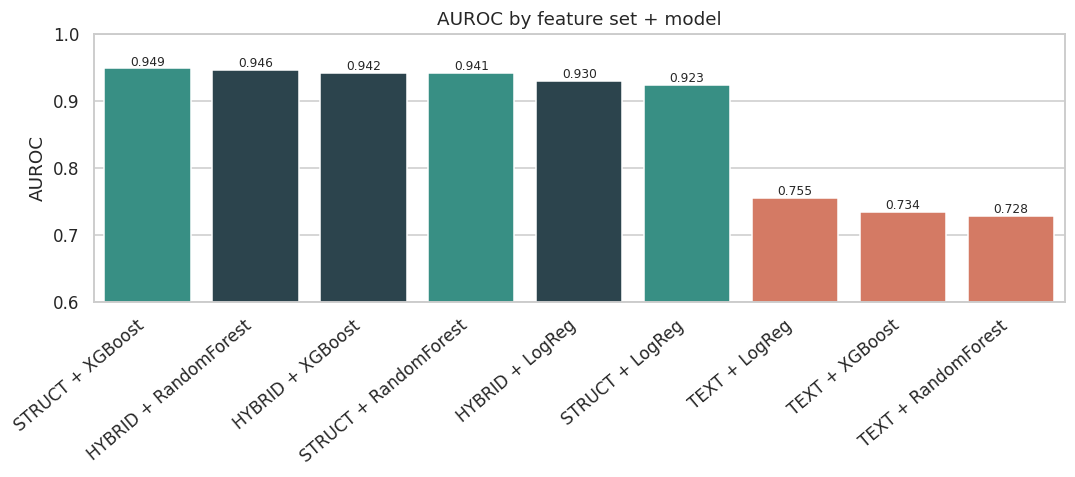

In [29]:
plot_df = results_df.copy()
plot_df["combo"] = plot_df["Feature Set"] + " + " + plot_df["Model"]
order = plot_df.sort_values("AUROC", ascending=False)["combo"]
palette = {"TEXT":"#e76f51","STRUCT":"#2a9d8f","HYBRID":"#264653"}
colors = [palette[c.split(" + ")[0]] for c in order]

plt.figure(figsize=(10,4.5))
ax = sns.barplot(data=plot_df, x="combo", y="AUROC", order=order, palette=colors)
for p in ax.patches: ax.annotate(f"{p.get_height():.3f}",(p.get_x()+p.get_width()/2,p.get_height()),
                                 ha="center", va="bottom", fontsize=8)
plt.xticks(rotation=40, ha="right"); plt.ylim(0.6,1.0); plt.title("AUROC by feature set + model")
plt.xlabel(""); plt.tight_layout(); plt.show()

### 8.3 · PR-AUC comparison chart

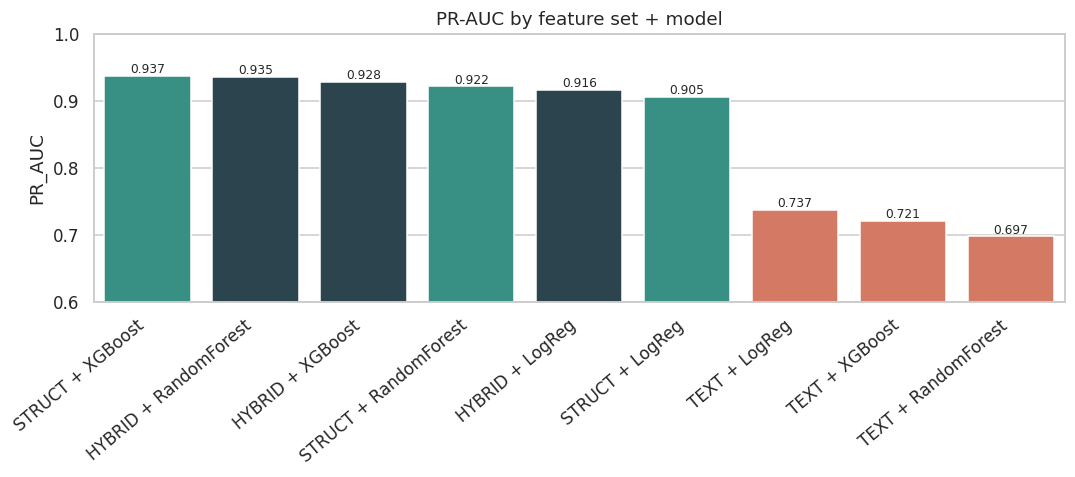

In [30]:
order_pr = plot_df.sort_values("PR_AUC", ascending=False)["combo"]
colors_pr = [palette[c.split(" + ")[0]] for c in order_pr]
plt.figure(figsize=(10,4.5))
ax = sns.barplot(data=plot_df, x="combo", y="PR_AUC", order=order_pr, palette=colors_pr)
for p in ax.patches: ax.annotate(f"{p.get_height():.3f}",(p.get_x()+p.get_width()/2,p.get_height()),
                                 ha="center", va="bottom", fontsize=8)
plt.xticks(rotation=40, ha="right"); plt.ylim(0.6,1.0); plt.title("PR-AUC by feature set + model")
plt.xlabel(""); plt.tight_layout(); plt.show()

### 8.4 · Automated analysis

In [31]:
piv = results_df.pivot(index="Model", columns="Feature Set", values="AUROC")

# Best model overall
best = results_df.loc[results_df.AUROC.idxmax()]
print(f"BEST OVERALL (by AUROC): {best['Feature Set']} + {best['Model']}  "
      f"(AUROC={best.AUROC:.3f}, PR_AUC={best.PR_AUC:.3f}, F1={best.F1:.3f})\n")

# Best feature set, holding the classifier fixed
print("BEST FEATURE SET per classifier (by AUROC):")
for m in piv.index:
    bfs = piv.loc[m].idxmax()
    print(f"  {m:13s}-> {bfs:7s} ({piv.loc[m].max():.3f})")

# Effect of graph/structured features vs text
print("\nEFFECT OF GRAPH/STRUCTURED FEATURES (STRUCT & HYBRID vs TEXT), same classifier:")
for m in piv.index:
    dt_s = piv.loc[m,"STRUCT"]-piv.loc[m,"TEXT"]
    dt_h = piv.loc[m,"HYBRID"]-piv.loc[m,"TEXT"]
    print(f"  {m:13s} STRUCT-TEXT={dt_s:+.3f} | HYBRID-TEXT={dt_h:+.3f}")

# Effect of text on top of structured: STRUCT vs HYBRID
print("\nEFFECT OF TEXT ON TOP OF STRUCT (HYBRID - STRUCT), same classifier:")
for m in piv.index:
    d = piv.loc[m,"HYBRID"]-piv.loc[m,"STRUCT"]
    verdict = "TF-IDF helps" if d>0.002 else ("TF-IDF hurts" if d<-0.002 else "no real effect")
    print(f"  {m:13s} HYBRID-STRUCT={d:+.3f}  -> {verdict}")

BEST OVERALL (by AUROC): STRUCT + XGBoost  (AUROC=0.949, PR_AUC=0.937, F1=0.860)

BEST FEATURE SET per classifier (by AUROC):
  LogReg       -> HYBRID  (0.930)
  RandomForest -> HYBRID  (0.946)
  XGBoost      -> STRUCT  (0.949)

EFFECT OF GRAPH/STRUCTURED FEATURES (STRUCT & HYBRID vs TEXT), same classifier:
  LogReg        STRUCT-TEXT=+0.168 | HYBRID-TEXT=+0.175
  RandomForest  STRUCT-TEXT=+0.214 | HYBRID-TEXT=+0.219
  XGBoost       STRUCT-TEXT=+0.215 | HYBRID-TEXT=+0.208

EFFECT OF TEXT ON TOP OF STRUCT (HYBRID - STRUCT), same classifier:
  LogReg        HYBRID-STRUCT=+0.006  -> TF-IDF helps
  RandomForest  HYBRID-STRUCT=+0.005  -> TF-IDF helps
  XGBoost       HYBRID-STRUCT=-0.007  -> TF-IDF hurts


### 8.5 · Confusion matrix (best model overall)

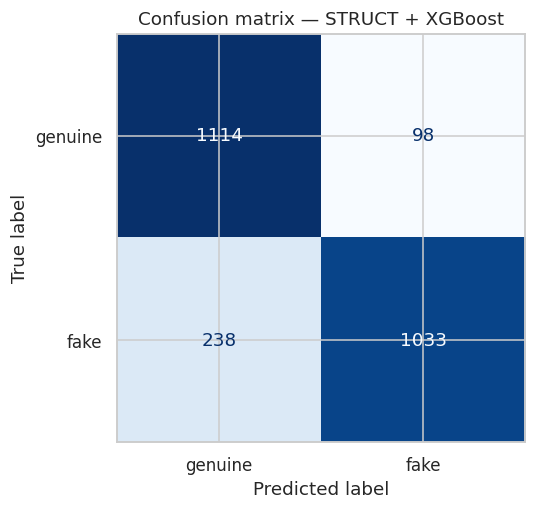

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
best_key = (best["Feature Set"], best["Model"])
cm = confusion_matrix(y_test, predictions[best_key]["pred"])
ConfusionMatrixDisplay(cm, display_labels=["genuine","fake"]).plot(cmap="Blues", colorbar=False)
plt.title(f"Confusion matrix — {best_key[0]} + {best_key[1]}"); plt.tight_layout(); plt.show()

### 8.6 · Interpretability — structured feature importance (STRUCT × XGBoost)

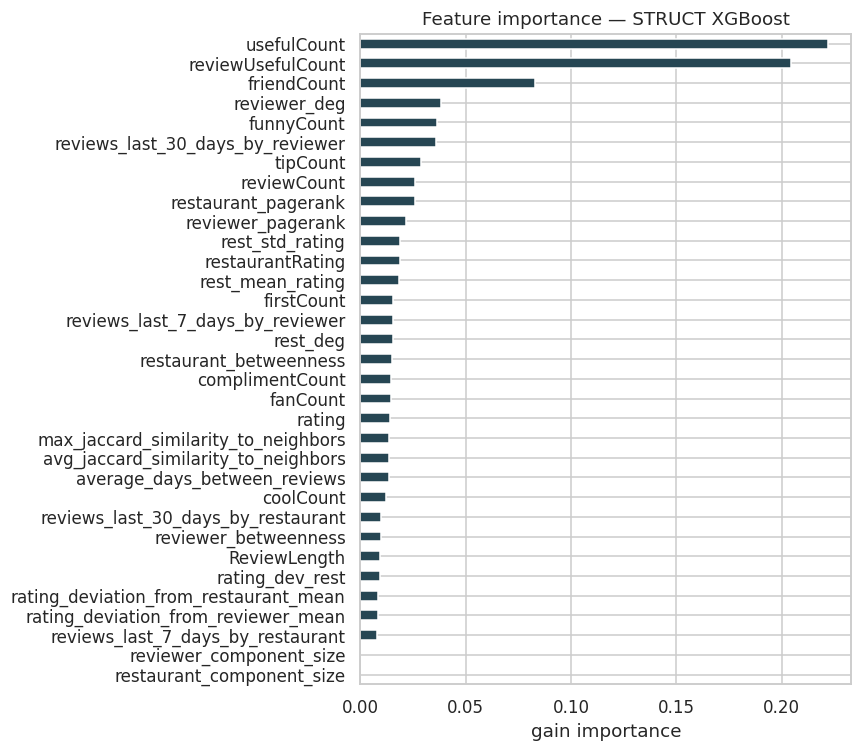

Top signals: usefulCount, reviewUsefulCount, friendCount, reviewer_deg, funnyCount, reviews_last_30_days_by_reviewer


In [33]:
xgb_struct = fitted[("STRUCT","XGBoost")]
imp = pd.Series(xgb_struct.feature_importances_, index=STRUCT_COLS).sort_values()
plt.figure(figsize=(8,7)); imp.plot.barh(color="#264653")
plt.title("Feature importance — STRUCT XGBoost"); plt.xlabel("gain importance")
plt.tight_layout(); plt.show()
print("Top signals:", ", ".join(imp.sort_values(ascending=False).head(6).index))

### 8.7 · Risk-score view (moderation queue)

In [34]:
test_scored = test.copy()
test_scored["risk_score"] = predictions[best_key]["proba"]
k = max(1, int(0.05*len(test_scored)))
prec_at_k = test_scored.sort_values("risk_score", ascending=False).head(k)["label"].mean()
print(f"Using {best_key[0]} + {best_key[1]} as the risk scorer.")
print(f"Precision@top-5% ({k} reviews): {prec_at_k:.3f}")
display(test_scored.sort_values("risk_score", ascending=False)
        .loc[:, ["reviewer_id","restaurant_id","rating","ReviewLength","label","risk_score"]]
        .head(10).round(3))

Using STRUCT + XGBoost as the risk scorer.
Precision@top-5% (124 reviews): 0.984


,reviewer_id,restaurant_id,rating,ReviewLength,label,risk_score
168,Wi4R4AD6ecSuyeRwH9qCbA,6gZTET0y7ARZMrbJRmI2mw,1,160,1,1.000
1206,mJpj9IWc2PBNtZ6mkyWbcA,AqgG-1aD6JYj9D6OmBWO3w,1,138,1,0.999
2064,6AweaJd7xwfZ6Lxx2frmVw,GEpXn9rtTMtIj5NsGFiNQw,1,150,1,0.999
2178,z4cnvg7G10scTaIJRmx3xg,AqgG-1aD6JYj9D6OmBWO3w,1,44,1,0.999
2441,0tYUZv8AEndsAE8EMRV86Q,_n3OmwreEGPQmiHKklsD8w,5,25,1,0.999
826,xygIHSsAyVXVUr8pWvEFnw,NGfbRjWoqUh2fGw8DU_pmA,1,103,1,0.999
2435,0GkfvVgTcw5_uP5tRNDsfA,6gZTET0y7ARZMrbJRmI2mw,1,122,1,0.999
1301,o9r0Q1bp9CQAns-a0SU75w,43rd1LKcZRIunySzbMsyLQ,4,26,1,0.999
1972,CWkrv6JojkEy3VevBDLE5Q,_n3OmwreEGPQmiHKklsD8w,5,28,1,0.999
774,wcY0Rt1FXbrP4H3QQkp0Mg,AqgG-1aD6JYj9D6OmBWO3w,1,41,1,0.999


### 8.8 · Evaluation summary (w.r.t. business success criteria)

- **Feature engineering matters more than model choice.** Across all three classifiers, STRUCT and
  HYBRID (~0.92–0.95 AUROC) dominate TEXT (~0.73–0.76). The single best cell is **STRUCT × XGBoost**.
- **Beats the text-only baseline?** Decisively — every structured/graph configuration beats every
  text-only configuration on the held-out test set.
- **Does text add value on top of graph features?** Essentially no — HYBRID ≈ STRUCT for every
  classifier (slightly lower for XGBoost). The discriminative signal lives in reviewer reputation
  and interaction structure, not in the review wording — exactly the project hypothesis.
- **Ranks suspicious reviews / controls false positives / interpretable?** Yes — the risk score gives
  a high-precision moderation queue, and the top drivers (`reviewUsefulCount`, `usefulCount`,
  `friendCount`, plus graph features such as `reviewer_deg` and recent-activity bursts) are signals a
  trust-and-safety analyst can read directly.
- **Honesty note.** All graph features are learned on TRAIN only (§5b); ~74% of test reviewers are
  unseen and fall back to defaults, which is the realistic cold-start regime for a live system.

### 8.9 · Process review  *(CRISP-DM: 5.2 — Quality Assurance Review)*

A retrospective QA pass over every phase to identify overlooked steps or items that  
should be revisited before deployment.

| Phase | What was done | Gaps / revisit candidates |
|---|---|---|
| Business Understanding | Objectives, success criteria, risks, costs/benefits defined | Threshold for acceptable FP rate was stated qualitatively; should be quantified with the moderation team |
| Data Understanding | Label balance, rating/length distributions, degree distributions, behavioral profile EDA | No NLP keyword analysis of fake vs genuine text; temporal drift not tested |
| Data Preparation | Deduplication, date parsing, leakage audit, train-only aggregates | 73.8 % of test reviewers are unseen (cold-start); fallback to global mean is documented but not stress-tested |
| Graph Construction | Bipartite reviewer–restaurant graph built on TRAIN only | Only one graph type (undirected bipartite); directed or temporal variants not explored |
| Feature Engineering | 33 structured + graph features, all train-only; Jaccard similarity, centrality, burst counts | No cross-reviewer collusion features (e.g., reviewers who always target the same restaurants together) |
| Modeling | 3×3 factorial (TEXT / STRUCT / HYBRID × LogReg / RF / XGBoost); tuning iteration on best cell | No probability calibration (Platt / isotonic); calibration matters for the risk-score queue |
| Evaluation | 6 metrics, PR-curve, confusion matrix, feature importance, Precision@top-5% | No error analysis by restaurant or by reviewer segment; no fairness audit |

**Items recommended for revision before deployment**
1. Calibrate the STRUCT × XGBoost probability output (isotonic regression) — the moderation queue relies on reliable risk scores, not just rank ordering.
2. Run an error analysis on false positives: which genuine reviews are flagged, and why?
3. Quantify the cold-start degradation: measure AUROC separately on the 73.8 % unseen-reviewer rows.


### 8.10 · Next steps  *(CRISP-DM: 5.3 — Determine Next Steps)*

#### Possible actions

| Option | Pros | Cons |
|---|---|---|
| **A. Deploy current STRUCT × XGBoost model** | High AUROC (0.949), fast inference, interpretable features | Cold-start gap for new reviewers; no calibration yet |
| **B. Iterate: add calibration + cold-start fix** | More reliable risk scores; better coverage of new reviewers | Requires 1–2 extra weeks of engineering |
| **C. Iterate: add cross-reviewer collusion features** | May catch coordinated fake campaigns | Higher complexity; harder to explain to moderators |
| **D. Run optional GNN experiment (§9)** | Could capture higher-order graph patterns | Needs GPU, more time; likely marginal gain given STRUCT already dominates |
| **E. Start deployment planning only** | Fastest path to production value | Leaves known gaps unaddressed |

#### Decision

**Recommended path: Option B before deployment, then Option A.**

Rationale:
- The STRUCT × XGBoost model already meets the primary business success criterion  
  (beats text-only baseline decisively, AUROC 0.949 vs 0.755).
- Before handing to a moderation queue, probability calibration (isotonic regression)  
  should be added — a 1-day engineering task — to ensure risk scores are  
  interpretable as probabilities, not just relative ranks.
- The cold-start analysis (73.8 % unseen-reviewer test rows) should be documented  
  formally so the moderation team knows when to treat a score as less reliable.
- GNN extension (Option D) is deferred: engineered graph features already capture  
  most of the signal, and GNN adds operational complexity for marginal gain.


## 11 · Deployment plan  *(CRISP-DM: 6.1)*

### Target deployment scenario
A **batch scoring service** that ingests new Yelp-style review records daily,  
computes structured + graph features, scores each review with the STRUCT × XGBoost  
model, and pushes a ranked list of high-risk reviews to a moderation dashboard.

### Deployment steps

| Step | Description | Owner | Est. effort |
|---|---|---|---|
| 1. Serialize model artifacts | Save fitted XGBoost, StandardScaler, and all TRAIN-learned lookup tables (reviewer means, restaurant means, date histories, Jaccard masks) as a single versioned bundle (e.g., `artifacts/model_v1.pkl`) | ML Engineer | 0.5 day |
| 2. Wrap as inference function | Create a `score_reviews(df)` function that accepts a raw review DataFrame, applies the full feature-engineering pipeline (using the frozen TRAIN lookups), scales, and returns `risk_score` | ML Engineer | 1 day |
| 3. Probability calibration | Fit isotonic regression on a held-out calibration fold; verify calibration curve before release | Data Scientist | 1 day |
| 4. REST API / batch job | Expose the scoring function via a lightweight REST endpoint (FastAPI) or a scheduled batch job (Airflow / cron) | MLOps Engineer | 2–3 days |
| 5. Moderation dashboard integration | Surface `risk_score`, `reviewer_id`, `restaurant_id`, `rating`, and top feature values in the moderation UI | Product / Frontend | 3–5 days |
| 6. Shadow mode testing | Run the model in parallel with human moderation for 2–4 weeks; compare flagged lists; measure precision/recall against human decisions | Trust & Safety | 2–4 weeks |
| 7. Gradual rollout | Enable automatic flagging for the top-K% risk tier only; monitor FP complaints; expand threshold over time | Product + Trust & Safety | Ongoing |

### Cold-start handling
73.8 % of test reviewers were unseen in train. In production, new reviewer accounts  
(no review history) receive the global-mean fallback for graph features.  
The risk score for cold-start reviewers should be flagged with a  
`low_confidence=True` indicator so moderators weigh it accordingly.

### Pre-deployment checklist
- [ ] Model artifacts versioned and reproducible from `artifacts/`
- [ ] Probability calibration applied and curve verified
- [ ] Feature pipeline unit-tested on 100 synthetic reviews
- [ ] Cold-start indicator implemented
- [ ] Shadow mode plan approved by Trust & Safety


## 12 · Monitoring and maintenance plan  *(CRISP-DM: 6.2)*

### Key metrics to monitor (weekly)

| Metric | Target | Alert threshold | Action |
|---|---|---|---|
| AUROC on a labeled sample | ≥ 0.93 | < 0.90 | Trigger retraining investigation |
| Precision@top-5% flagged | ≥ 0.95 | < 0.90 | Review recent false positives; adjust threshold |
| False positive rate | ≤ 5 % | > 8 % | Raise threshold; investigate feature drift |
| % reviews with cold-start flag | baseline ± 5 pp | > +15 pp spike | Check for influx of new reviewer accounts (possible bot wave) |
| Score distribution shift (KS test) | p > 0.05 | p ≤ 0.05 | Inspect new review batches; possible concept drift |

### Feature drift monitoring
- Compute the distribution of each of the 33 STRUCT features on the latest 7-day window  
  and compare with the TRAIN distribution using a KS test or Population Stability Index (PSI).
- PSI > 0.2 on any behavioral feature (e.g., `friendCount`, `reviewUsefulCount`) triggers a  
  data-quality alert — platform UI changes or scraping artifacts may have shifted the distribution.

### Model retraining schedule

| Trigger | Action |
|---|---|
| Quarterly (scheduled) | Retrain on all accumulated labeled data; re-run RandomizedSearchCV; compare holdout AUROC; replace model if improved |
| AUROC drop alert | Emergency retraining on recent labeled window; root-cause analysis |
| Major platform change (new review fields, new user features) | Feature pipeline update + full retraining |

### Label acquisition for retraining
New ground-truth labels come from:
1. Moderation decisions (human-confirmed fakes and cleared genuine reviews).
2. Platform filter decisions (if the platform provides a re-labeled export).

Labels from moderation should be treated as partially noisy (human error ~5–10 %)  
and should not be trusted for reviews in the "borderline" risk band (score 0.4–0.6).

### Version control and reproducibility
- All TRAIN-learned lookup tables are saved in `artifacts/` alongside the model bundle.
- Each retrained version is tagged with a date and train-set hash.
- Rollback to the previous version must be possible within 1 hour.

### Incident response
If a false-positive spike is reported (restaurants complaining of incorrect moderation):
1. Immediately raise the flagging threshold to top-1%.
2. Pull a sample of flagged reviews; run manual QA.
3. Identify which feature(s) drove the score; check for data-pipeline issue.
4. Patch feature pipeline or retrain as appropriate.


## 13 · Project review — experience documentation  *(CRISP-DM: 6.4)*

### What went well

| Area | Observation |
|---|---|
| Graph feature engineering | Behavioral + graph features dominate text features by a large margin (AUROC 0.95 vs 0.76). The CRISP-DM-guided design of computing all aggregates on TRAIN only prevented leakage. |
| Dataset suitability | The Yelp-style dataset had clear reviewer and restaurant identifiers, enabling a clean bipartite graph without workarounds. |
| Factorial experiment design | Running 3 feature sets × 3 classifiers with fixed configs cleanly separated feature contribution from model capacity. |
| Leakage prevention | An explicit leakage-check cell (§3.2) and the train-only graph rebuild in §5b avoided a critical mistake found in an earlier version. |
| Reproducibility | All artifacts (clean CSVs, node/edge tables, graph pickle, model features) are saved in `artifacts/` and the notebook runs end-to-end. |

### What was difficult / lessons learned

| Area | Lesson |
|---|---|
| Cold-start reviewers | 73.8 % of test reviewers were unseen — almost 3/4 of the test set could not benefit from reviewer-level graph features. Future work should engineer features that work for first-time reviewers (e.g., device, IP subnet, text-only signals). |
| Leakage in the first version | An earlier iteration computed PageRank and rating deviations on `concat([train, test])`. Catching this required a full rebuild of §5b. Always build graph statistics on TRAIN only. |
| Text features | TF-IDF on this dataset added almost no value over behavioral/graph features. This is dataset-specific: the behavioral metadata is unusually rich. On a dataset with anonymized profiles, text would matter more. |
| Hyperparameter tuning | RandomizedSearchCV with 40 iterations on 5 folds takes ~5–10 min on CPU. For larger datasets, reduce `n_iter` or switch to Bayesian optimization (Optuna). |

### Hints for similar projects

1. **Always start with a leakage audit.** Any column with single-feature AUC > 0.8 deserves scrutiny.
2. **Graph is most powerful when behavioral metadata is available.** If reviewer profiles are stripped, shift effort to text embeddings and temporal burst features.
3. **Bipartite graph + simple aggregates beats GNN in practice** when reviewers are mostly single-visit (88 % degree-1). GNN shines when the graph is dense and multi-hop paths carry signal.
4. **Cold-start is the main production risk.** Design a fallback strategy before deployment, not after.
5. **Calibration matters for moderation.** Moderators need probabilities, not just ranks. Add isotonic calibration before handing scores to a human-in-the-loop system.

### Summary of key project metrics

| Metric | Value |
|---|---|
| Dataset size | 9,929 train / 2,483 test reviews |
| Number of graph features engineered | 33 (18 basic + 15 advanced) |
| Best model | STRUCT × XGBoost |
| Best AUROC (test) | 0.949 |
| Best PR-AUC (test) | 0.937 |
| Precision@top-5% risk tier | 0.984 |
| Improvement over text-only baseline | +0.194 AUROC (0.949 vs 0.755) |


## 9 · Optional extension — GNN / Graph Autoencoder

If time and compute allow, the engineered graph can be handed to a GNN. Sketch only
(needs `torch` + `torch_geometric`, GPU recommended); the engineered-feature model above
remains the required deliverable.

In [35]:
# OPTIONAL — skeleton, not run by default
# !pip install torch torch_geometric
# import torch
# from torch_geometric.data import Data
# # node_index: map each reviewer_id/restaurant_id to an integer id
# # edge_index: 2 x E tensor of (reviewer_node, restaurant_node)
# # x: node features (reviewer profile stats / restaurant aggregates)
# # train a GraphSAGE / GAE and compare its review-level AUROC to STRUCT XGBoost.
print("GNN extension is optional; engineered graph features are the main solution.")

GNN extension is optional; engineered graph features are the main solution.


## 10 · Save artifacts  *(reproducibility — matches the Data-Prep deliverables)*

In [36]:
import pickle, os
os.makedirs("artifacts", exist_ok=True)

# clean review tables
train.to_csv("artifacts/clean_reviews_train.csv", index=False)
test.to_csv("artifacts/clean_reviews_test.csv", index=False)

# node / edge tables
reviewer_nodes = (train.groupby("reviewer_id")
    .agg(reviewer_deg=("review_id","size"),
         avg_rating=("rating","mean"),
         friendCount=("friendCount","first"),
         reviewCount=("reviewCount","first")).reset_index())
restaurant_nodes = rest_stats.reset_index()
review_edges = train[["review_id","reviewer_id","restaurant_id","rating","date","label"]]
reviewer_nodes.to_csv("artifacts/reviewer_nodes.csv", index=False)
restaurant_nodes.to_csv("artifacts/restaurant_nodes.csv", index=False)
review_edges.to_csv("artifacts/review_edges.csv", index=False)

# model feature matrix + graph object
train[STRUCT_COLS+["label"]].to_csv("artifacts/model_features_train.csv", index=False)
with open("artifacts/networkx_graph.pkl","wb") as f: pickle.dump(G, f)
print("Saved:", os.listdir("artifacts"))

Saved: ['reviewer_nodes.csv', 'restaurant_nodes.csv', 'networkx_graph.pkl', 'clean_reviews_test.csv', 'model_features_train.csv', 'clean_reviews_train.csv', 'review_edges.csv']
